<a href="https://colab.research.google.com/github/ojassahu29/Ensemble-Learning-Techniques/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Learning: Obesity Risk Prediction Project

This project focuses on predicting the risk of obesity using **Ensemble Learning techniques**. By combining the strengths of multiple machine learning models, the aim is to achieve more accurate and robust predictions compared to using a single model alone.

##  Objective:
To classify individuals into different obesity risk categories based on lifestyle, demographic, and health-related features using a stacked ensemble of base models.

##  Key Highlights:
- **Preprocessing**: Categorical encoding, feature scaling, and train-test splitting
- **Models Used**: Decision Tree, K-Nearest Neighbors (KNN), Logistic Regression
- **Evaluation Metrics**: Accuracy, Weighted Average Precision, Recall and F1-score, Confusion Matrix, and Classification Report

## Outcome:
The ensemble approach improved the overall prediction performance, showing better generalization across the dataset and handling feature interactions more effectively.

## By: Ojas Sahu (2023A3PS0861G)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
!pip install xgboost --quiet
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from itertools import product
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

###  Data Preprocessing

I prepared the dataset by handling categorical varaibles, scaling the numerical features for better results, and splitting the data

Steps taken in the next cell.
- Dropped the 'id' column as it holds no predictive value.
- Encoded all categorical (non-numeric) features using Label Encoding.
- Separated features (X) from the target variable (y).
- Performed train-test split (80-20) to evaluate model performance.
- Standardized the numerical features for better performance with logistic regression.



In [ ]:
df = pd.read_csv("dataset.csv")

#dropped the "id" column since it is not relevant for the prediction and is just for our reference
df.drop(columns=['id'], inplace=True)

# Encoding all features that have a text label into numeric value using LabelEncoder
label_encoder = {}
for col in df.columns:
    if df[col].dtype == 'object':
          le = LabelEncoder()
          df[col] = le.fit_transform(df[col])
          label_encoder[col] = le


# Separating of features (X) and target variable (y)
X=df.drop('NObeyesdad', axis=1)
y=df['NObeyesdad']

# Splitting the data into training and testing sets for checking if the model is underfitting or overfitting.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''
Normalising the data so that all the features are on the same scale so that the model does not get biased towards the larger numbers
just because of the higher value.

'''

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,2,0,2.763573,0,0.000000,0.976473,1,3,6
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,1,0,2.000000,0,1.000000,1.000000,2,0,1
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,2,0,1.910378,0,0.866045,1.673584,2,3,0
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,2,0,1.674061,0,1.467863,0.780199,1,3,4
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,2,0,1.979848,0,1.967973,0.931721,1,3,6


#### Label Encoding of Categorical Features

Several features in our dataset were categorical (text-based), which machine learning models cannot process directly. So I applied **Label Encoding** using `LabelEncoder` from scikit-learn to convert it into numerical value.

Here’s the encoding applied:

- **Gender**: 'Female' → 0, 'Male' → 1  
- **family_history_with_overweight**: 'no' → 0, 'yes' → 1  
- **FAVC** (Frequent high-calorie food): 'no' → 0, 'yes' → 1  
- **CAEC** (Eating between meals): 'Always' → 0, 'Frequently' → 1, 'Sometimes' → 2, 'no' → 3  
- **SMOKE**: 'no' → 0, 'yes' → 1  
- **SCC** (Calories monitoring): 'no' → 0, 'yes' → 1  
- **CALC** (Alcohol consumption): 'Frequently' → 0, 'Sometimes' → 1, 'no' → 2  
- **MTRANS** (Transport method): 'Automobile' → 0, 'Bike' → 1, 'Motorbike' → 2, 'Public_Transportation' → 3, 'Walking' → 4  
- **NObeyesdad** (Target variable - Obesity category):  
    - 'Insufficient_Weight' → 0  
    - 'Normal_Weight' → 1  
    - 'Obesity_Type_I' → 2  
    - 'Obesity_Type_II' → 3  
    - 'Obesity_Type_III' → 4  
    - 'Overweight_Level_I' → 5  
    - 'Overweight_Level_II' → 6  

This encoding allows us to train our machine learning models on numeric data while preserving the meaning of the original categories.


### Traditional Model Comparison – Logistic Regression, KNN, and Decision Tree

For selecting the most effective baseline model, I'll train three standard classifiers:
- **Logistic Regression**
- **K-Nearest Neighbors (KNN)**
- **Decision Tree**

Each model is evaluated on:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The same criterias that is told to be used for evaluation.

# Logistic Regression

 Classification Report for the logistic regression model: 

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       524
           1       0.85      0.80      0.82       626
           2       0.82      0.84      0.83       543
           3       0.95      0.97      0.96       657
           4       1.00      1.00      1.00       804
           5       0.70      0.70      0.70       484
           6       0.72      0.68      0.70       514

    accuracy                           0.86      4152
   macro avg       0.85      0.85      0.85      4152
weighted avg       0.86      0.86      0.86      4152




Accuracy: 0.8625
Precision: 0.8609
Recall:    0.8625
F1 Score:  0.8613


Confusion Matrix for Logistic Regression


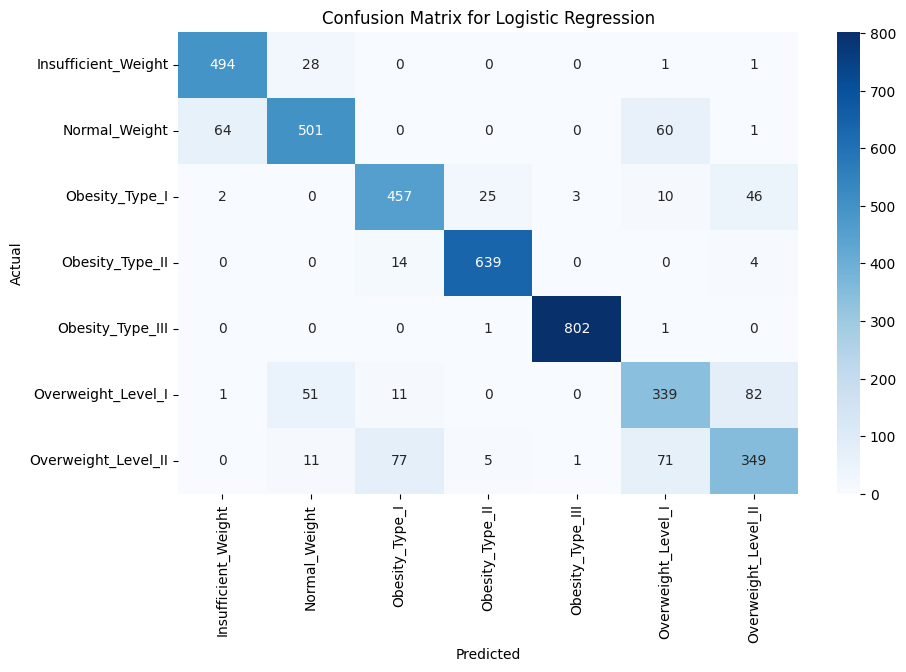

In [ ]:
# Creating a Logistic regression model using sklearn
# solver = "lbfgs" since it is suitable for multinomial loss
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000)
lr_model.fit(X_train, y_train)

# makes the prediction based on test sets
y_pred_lr = lr_model.predict(X_test)

# Evaluating the performance using classification report
print(" Classification Report for the logistic regression model: \n")
print(classification_report(y_test, y_pred_lr))
print("\n\n")

# Accuracy, Precision, Recall, F1-score for the model as evaluation metrics
acc_lr=accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f}")
prec_lr=precision_score(y_test, y_pred_lr, average='weighted')
print(f"Precision: {prec_lr:.4f}")
rec_lr=recall_score(y_test, y_pred_lr, average='weighted')
print(f"Recall:    {rec_lr:.4f}")
f1_lr=f1_score(y_test, y_pred_lr, average='weighted')
print(f"F1 Score:  {f1_lr:.4f}\n\n")

# Plotting the confusion matrix for logistic model
print("Confusion Matrix for Logistic Regression")
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# K-Nearest Neighbors (KNN)

I used:
- `k = 5` (default value)
- Euclidean distance for proximity
- Evaluation using classification report and confusion matrix


 Classification Report for the KNN model: 

              precision    recall  f1-score   support

           0       0.73      0.77      0.75       524
           1       0.56      0.62      0.59       626
           2       0.64      0.72      0.68       543
           3       0.92      0.93      0.92       657
           4       1.00      1.00      1.00       804
           5       0.51      0.40      0.45       484
           6       0.61      0.54      0.57       514

    accuracy                           0.74      4152
   macro avg       0.71      0.71      0.71      4152
weighted avg       0.74      0.74      0.73      4152

Accuracy:  0.7377
Precision: 0.7350
Recall:    0.7377
F1 Score:  0.7347


Confusion Matrix for KNN


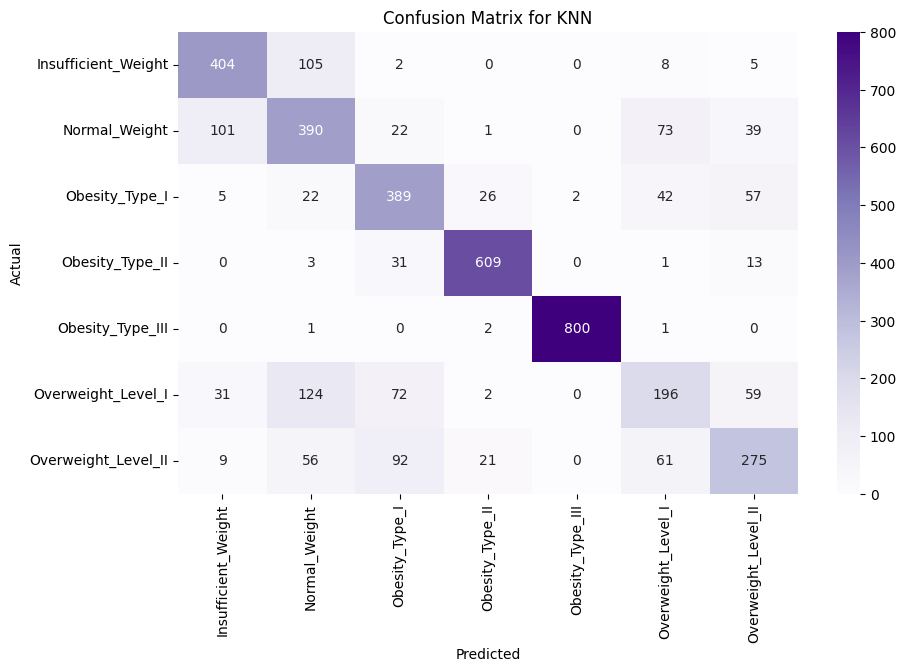

In [ ]:
# Training the K Nearest Neighbours model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predicting on the test set data
y_pred_knn = knn_model.predict(X_test)

# Evaluating the performance using classification report
print(" Classification Report for the KNN model: \n")
print(classification_report(y_test, y_pred_knn))

# Accuracy, Precision, Recall, F1-score
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy:  {acc_knn:.4f}")
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
print(f"Precision: {prec_knn:.4f}")
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
print(f"Recall:    {rec_knn:.4f}")
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(f"F1 Score:  {f1_knn:.4f}\n\n")

# Confusion Matrix calculation and plotting
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix for KNN")
plt.figure(figsize=(10, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN')
plt.show()

For different values of n_neighbours, the evaluation metrics don't deviate away much and it makes little to no difference.

# Decision Tree Classifier

 Classification Report for the Decision Tree model: 

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       524
           1       0.78      0.77      0.78       626
           2       0.83      0.83      0.83       543
           3       0.95      0.95      0.95       657
           4       0.99      1.00      0.99       804
           5       0.65      0.65      0.65       484
           6       0.71      0.71      0.71       514

    accuracy                           0.84      4152
   macro avg       0.83      0.83      0.83      4152
weighted avg       0.84      0.84      0.84      4152

Accuracy:  0.8439
Precision: 0.8437
Recall:    0.8439
F1 Score:  0.8438




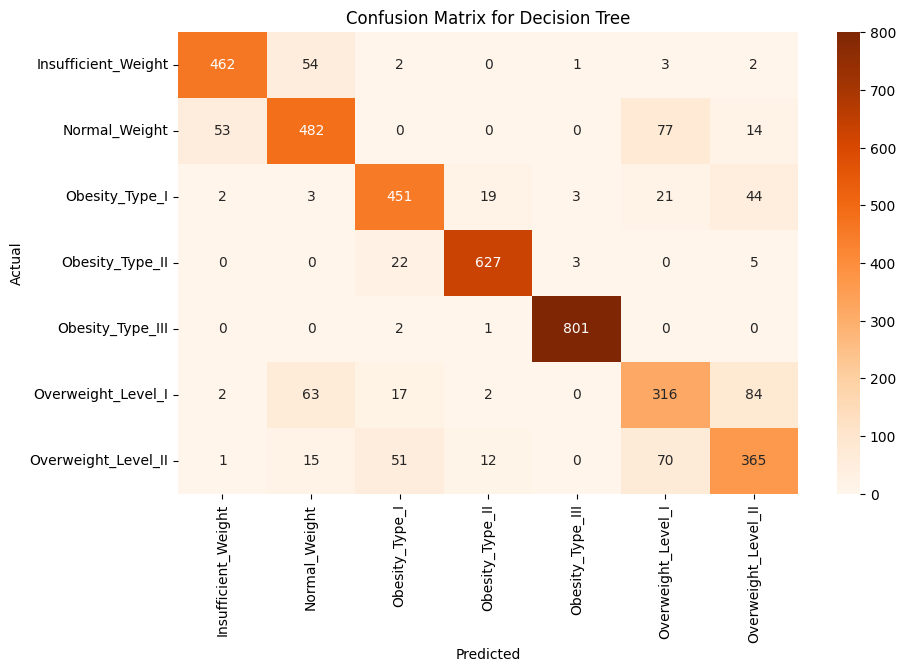

In [ ]:
# Training the Decision Tree model
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Prediction on the test set data
y_pred_dt=dt_model.predict(X_test)

# Classification report for the model
print(" Classification Report for the Decision Tree model: \n")
print(classification_report(y_test, y_pred_dt))

# Accuracy, Precision, Recall, F1-score for DT
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy:  {acc_dt:.4f}")
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
print(f"Precision: {prec_dt:.4f}")
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
print(f"Recall:    {rec_dt:.4f}")
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"F1 Score:  {f1_dt:.4f}\n\n")

# Confusion matrix for the same
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(10,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

## Let's see the comparison between the three traditional ML models we have used

In [ ]:
data = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_knn, acc_dt],
    'Precision': [prec_lr, prec_knn, prec_dt],
    'Recall': [rec_lr, rec_knn, rec_dt],
    'F1-Score': [f1_lr, f1_knn, f1_dt]
}

df_results = pd.DataFrame(data)

display(
    df_results.style.set_caption("Traditional Model Performance Comparison")
                      .format({'Accuracy': "{:.4f}", 'Precision': "{:.4f}", 'Recall': "{:.4f}", 'F1-Score': "{:.4f}"})
                      .set_properties(**{'text-align': 'center'})
                      .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8625,0.8609,0.8625,0.8613
1,KNN,0.7377,0.7350,0.7377,0.7347
2,Decision Tree,0.8439,0.8437,0.8439,0.8438


## Conclusion drawn from the above

Among all three traditional models, Logistic Regression outperformed both K-Nearest Neighbours and Decision Tree. Logistic regression has the highest accuracy (86.25), F1-score (86.13) and precision (86.09). This directly means that the data is relatively linearly seperable and the logistic regression model is able to learn the boundaries without overfitting, unlike the more flexible Decision tree. Although the values of accuracy, precision, recall and F1-score in the Decision tree classifier is very close to the Logistic regression one, I'll be proceeding with logistic regression as the best traditional model to be used in this particular case for baseline

# Ensemble Techniques to be explored


## ->Bagging (Bootstrap Aggregating)

Bagging (Bootstrap Aggregating) trains several base models independently on different random subsets of training data. Each subset is drawn with replacement (bootstrapped). The final prediction will be made by majority vote.

Random Forest is going to be used here for the Bagging technique. It will have multiple decision trees in parallel with different randomised subset of training data to train on and each tree will give an output based on that training data. In the end, a final majority vote will be taken. This is more effiecient than a single decision tree.


 Classification Report for the Random Forest model: 

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       524
           1       0.84      0.88      0.86       626
           2       0.88      0.86      0.87       543
           3       0.98      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.78      0.75      0.77       484
           6       0.78      0.80      0.79       514

    accuracy                           0.90      4152
   macro avg       0.89      0.88      0.88      4152
weighted avg       0.90      0.90      0.90      4152

Accuracy:  0.8960
Precision: 0.8962
Recall:    0.8960
F1 Score:  0.8959




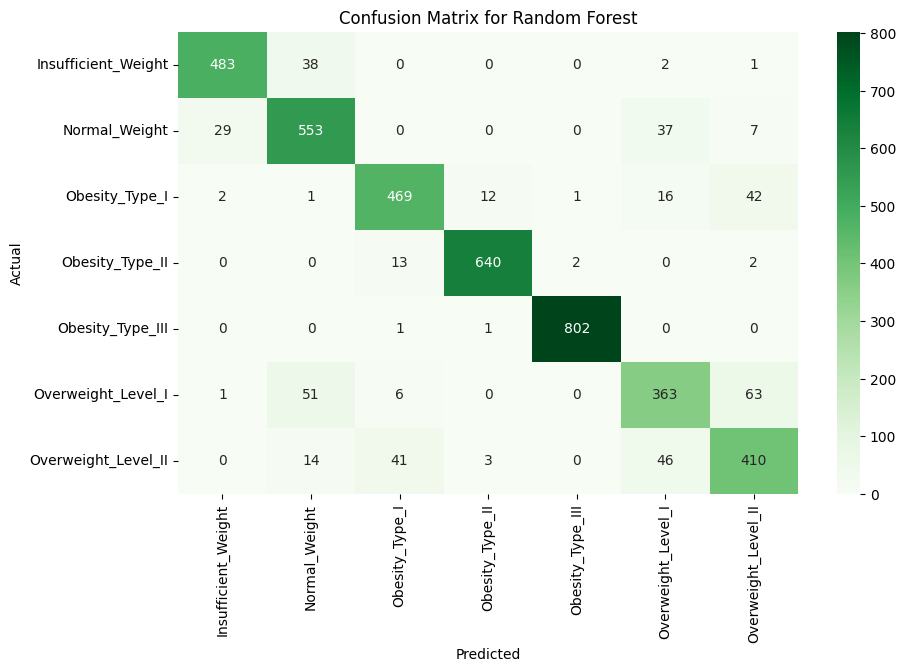

In [ ]:
# Training the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Making predicitions on the test dataset
y_pred_rf = rf_model.predict(X_test)

# Classification Report for this model
print(" Classification Report for the Random Forest model: \n")
print(classification_report(y_test, y_pred_rf))

# Evaluation metrics for this model
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy:  {acc_rf:.4f}")
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
print(f"Precision: {prec_rf:.4f}")
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
print(f"Recall:    {rec_rf:.4f}")
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1 Score:  {f1_rf:.4f}\n\n")

# Consfusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

 Below is the side by side comparison between the Random Forest Algorithm and a Single Decision Tree

In [ ]:
comparison_data = {
    'Model': ['Decision Tree', 'Random Forest (Bagging)'],
    'Accuracy': [acc_dt, acc_rf],
    'Precision': [prec_dt, prec_rf],
    'Recall': [rec_dt, rec_rf],
    'F1-Score': [f1_dt, f1_rf]
}

df_compare_rf_dt = pd.DataFrame(comparison_data)

display(
    df_compare_rf_dt.style.set_caption("Side-by-Side Comparison: Decision Tree vs Random Forest")
                           .format({'Accuracy': "{:.4f}", 'Precision': "{:.4f}", 'Recall': "{:.4f}", 'F1-Score': "{:.4f}"})
                           .set_properties(**{'text-align': 'center'})
                           .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8439,0.8437,0.8439,0.8438
1,Random Forest (Bagging),0.8960,0.8962,0.8960,0.8959


As you can see, there is visible improvement in accuracy, precision, recall and F1-score when gone from Decision tree to Random Forest algorithm.

## ->Boosting Technique

This is very similar to the bagging technique except that the models are trained sequentially and not in parallel. Each model focuses on fixing the mistakes of its previous model. In the end, the final prediction is the weighted combination of all models. The reason why this is suited for classification is because it helps correct difficult cases by giving them more importance in the later models.

The particular boosting method that will be used is Adaptive boosting (AdaBoost). It uses decision trees and assigns more weight to the misclassified samples in each round.

 Classification Report for the AdaBoost model: 

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       524
           1       0.86      0.86      0.86       626
           2       0.89      0.87      0.88       543
           3       0.97      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.75      0.76      0.76       484
           6       0.79      0.81      0.80       514

    accuracy                           0.90      4152
   macro avg       0.89      0.89      0.89      4152
weighted avg       0.90      0.90      0.90      4152

Accuracy:  0.8967
Precision: 0.8972
Recall:    0.8967
F1 Score:  0.8969




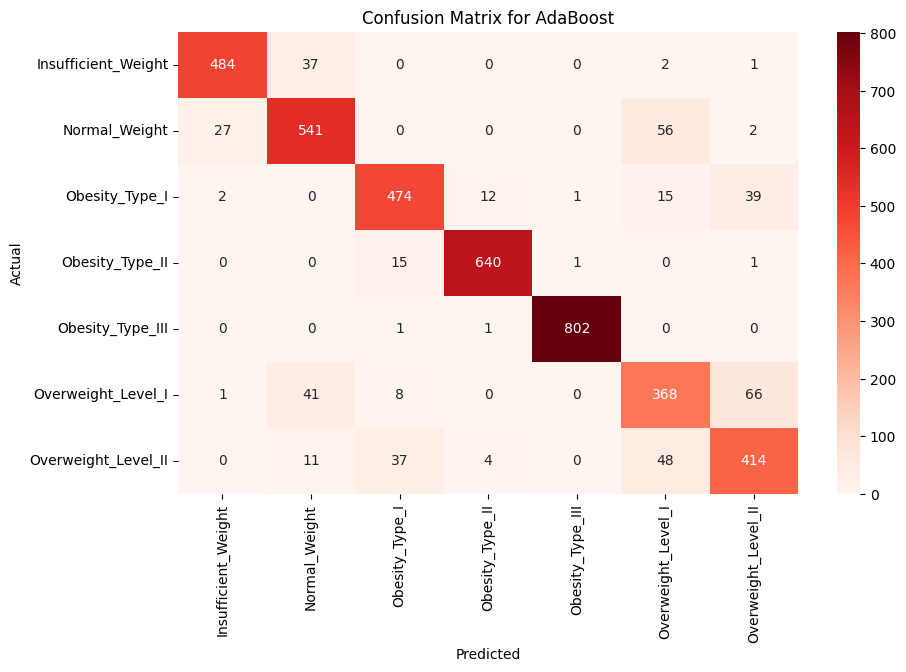

In [ ]:
# Training the model
best_est = DecisionTreeClassifier(max_depth=10)
ada_model = AdaBoostClassifier(estimator=best_est, n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

# Predict on the test set
y_pred_ada = ada_model.predict(X_test)

# Classification Report
print(" Classification Report for the AdaBoost model: \n")
print(classification_report(y_test, y_pred_ada))

# Accuracy, Precision, Recall and F1-score
acc_ada = accuracy_score(y_test, y_pred_ada)
print(f"Accuracy:  {acc_ada:.4f}")
prec_ada = precision_score(y_test, y_pred_ada, average='weighted')
print(f"Precision: {prec_ada:.4f}")
rec_ada = recall_score(y_test, y_pred_ada, average='weighted')
print(f"Recall:    {rec_ada:.4f}")
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')
print(f"F1 Score:  {f1_ada:.4f}\n\n")

# Confusion Matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(10,6))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for AdaBoost')
plt.show()

If the max depth is decreased from 10 to 3, the evaluation metrics decrease along with it. The code below demonstrates that, as it is the same code as the one above only with the change in max depth from 10 to 3.

 Classification Report for the AdaBoost model: 

              precision    recall  f1-score   support

           0       0.93      0.81      0.86       524
           1       0.74      0.85      0.79       626
           2       0.80      0.86      0.83       543
           3       0.95      0.98      0.96       657
           4       1.00      1.00      1.00       804
           5       0.69      0.64      0.67       484
           6       0.76      0.70      0.73       514

    accuracy                           0.85      4152
   macro avg       0.84      0.83      0.83      4152
weighted avg       0.85      0.85      0.85      4152

Accuracy:  0.8512
Precision: 0.8526
Recall:    0.8512
F1 Score:  0.8503




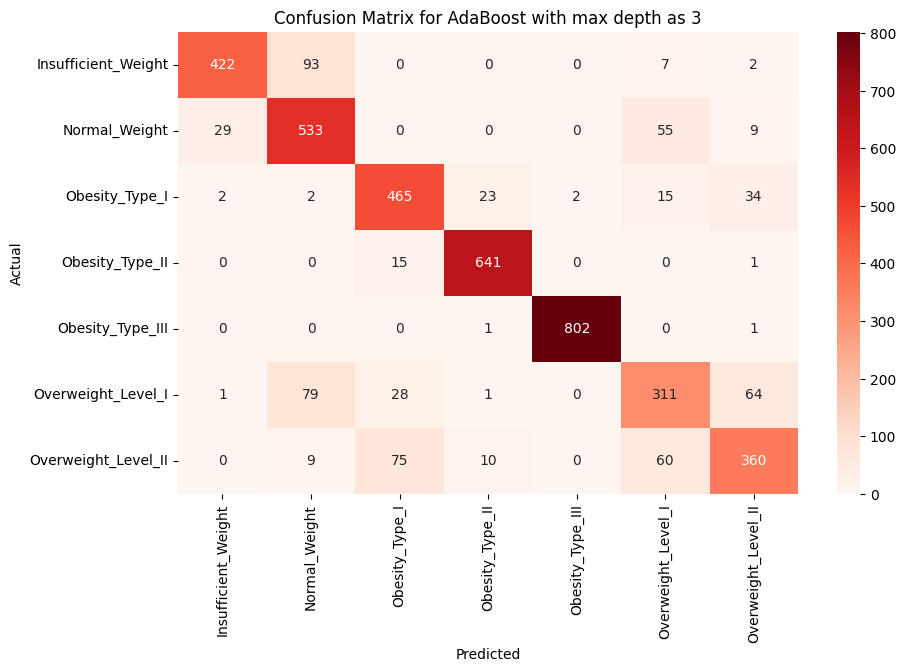

In [ ]:
# Training the model
best_est = DecisionTreeClassifier(max_depth=3) #max depth is changed from 10 to 3 in this case
ada_model3 = AdaBoostClassifier(estimator=best_est, n_estimators=100, random_state=42)
ada_model3.fit(X_train, y_train)

# Predict on the test set
y_pred_ada3 = ada_model3.predict(X_test)

# Classification Report
print(" Classification Report for the AdaBoost model: \n")
print(classification_report(y_test, y_pred_ada3))

# Accuracy, Precision, Recall and F1-score
acc_ada3 = accuracy_score(y_test, y_pred_ada3)
print(f"Accuracy:  {acc_ada3:.4f}")
prec_ada3 = precision_score(y_test, y_pred_ada3, average='weighted')
print(f"Precision: {prec_ada3:.4f}")
rec_ada3 = recall_score(y_test, y_pred_ada3, average='weighted')
print(f"Recall:    {rec_ada3:.4f}")
f1_ada3 = f1_score(y_test, y_pred_ada3, average='weighted')
print(f"F1 Score:  {f1_ada3:.4f}\n\n")

# Confusion Matrix
cm_ada3 = confusion_matrix(y_test, y_pred_ada3)
plt.figure(figsize=(10,6))
sns.heatmap(cm_ada3, annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for AdaBoost with max depth as 3')
plt.show()

Same pattern is noticed if the max depth is changed from 3 to 1

 Classification Report for the AdaBoost model (max depth = 1): 

              precision    recall  f1-score   support

           0       0.73      0.69      0.71       524
           1       0.59      0.69      0.63       626
           2       0.38      0.69      0.49       543
           3       0.73      0.20      0.31       657
           4       0.93      0.96      0.95       804
           5       0.69      0.37      0.48       484
           6       0.57      0.73      0.64       514

    accuracy                           0.63      4152
   macro avg       0.66      0.62      0.60      4152
weighted avg       0.68      0.63      0.62      4152

Accuracy:  0.6337
Precision: 0.6783
Recall:    0.6337
F1 Score:  0.6183




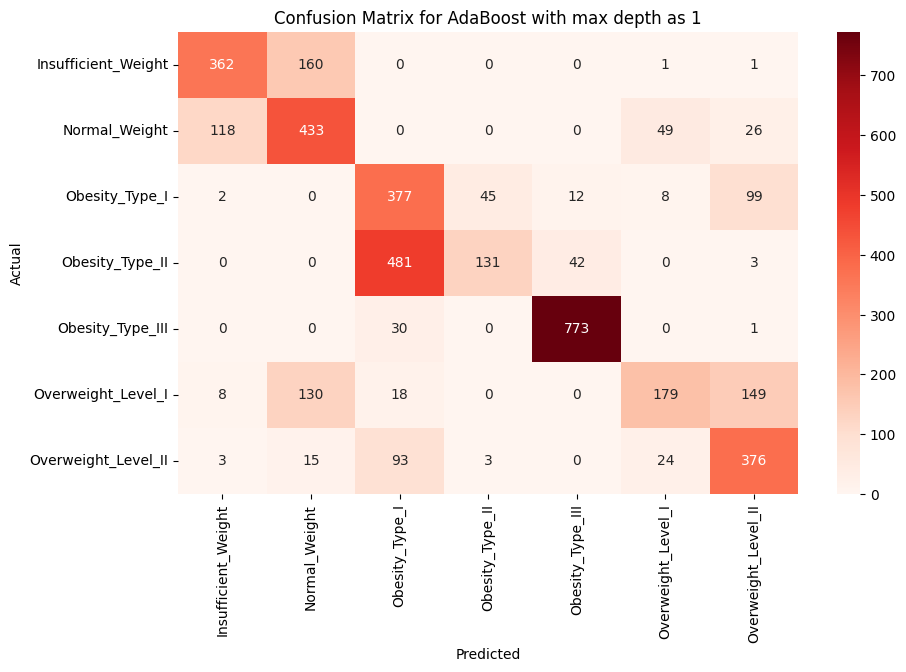

In [ ]:
# Training the model
best_est = DecisionTreeClassifier(max_depth=1)  # max depth is changed from 10 to 1 in this case
ada_model1 = AdaBoostClassifier(estimator=best_est, n_estimators=100, random_state=42)
ada_model1.fit(X_train, y_train)

# Predict on the test set
y_pred_ada1 = ada_model1.predict(X_test)

# Classification Report
print(" Classification Report for the AdaBoost model (max depth = 1): \n")
print(classification_report(y_test, y_pred_ada1))

# Accuracy, Precision, Recall and F1-score
acc_ada1 = accuracy_score(y_test, y_pred_ada1)
print(f"Accuracy:  {acc_ada1:.4f}")
prec_ada1 = precision_score(y_test, y_pred_ada1, average='weighted')
print(f"Precision: {prec_ada1:.4f}")
rec_ada1 = recall_score(y_test, y_pred_ada1, average='weighted')
print(f"Recall:    {rec_ada1:.4f}")
f1_ada1 = f1_score(y_test, y_pred_ada1, average='weighted')
print(f"F1 Score:  {f1_ada1:.4f}\n\n")

# Confusion Matrix
cm_ada1 = confusion_matrix(y_test, y_pred_ada1)
plt.figure(figsize=(10,6))
sns.heatmap(cm_ada1, annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for AdaBoost with max depth as 1')
plt.show()


The general trend is that the evaluation metrics decreases with the decrease in max depth but it was found that this pattern was not strict and that there were exceptions that did not follow the general trend.

Decision tree base model with max depth 3 trained
Decision tree base model with max depth 4 trained
Decision tree base model with max depth 5 trained
Decision tree base model with max depth 6 trained
Decision tree base model with max depth 7 trained
Decision tree base model with max depth 8 trained
Decision tree base model with max depth 9 trained
Decision tree base model with max depth 10 trained
Decision tree base model with max depth 11 trained
Decision tree base model with max depth 12 trained
Decision tree base model with max depth 13 trained
Decision tree base model with max depth 14 trained
Decision tree base model with max depth 15 trained
Decision tree base model with max depth 16 trained
Decision tree base model with max depth 17 trained
Decision tree base model with max depth 18 trained
Decision tree base model with max depth 19 trained
Decision tree base model with max depth 20 trained


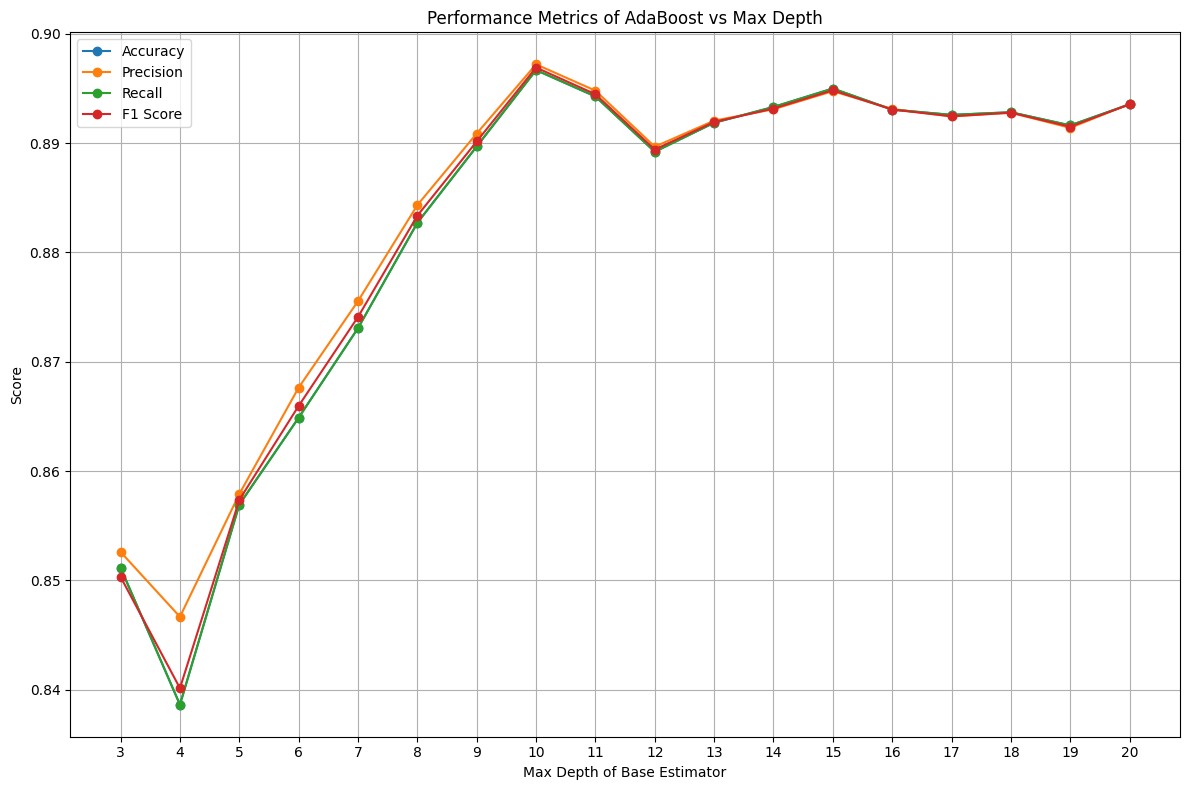

Highest Accuracy:  0.8967 at max_depth = 10
Highest Precision: 0.8972 at max_depth = 10
Highest Recall:    0.8967 at max_depth = 10
Highest F1 Score:  0.8969 at max_depth = 10


In [ ]:
# Initialising lists to store metrics in them for multiple depths
depths = list(range(3, 21))
accuracies = []
precisions = []
recalls = []
f1_scores = []

for depth in depths:
    # Defining base estimator with current max_depth
    base_est = DecisionTreeClassifier(max_depth=depth)
    ada_model = AdaBoostClassifier(estimator=base_est, n_estimators=100, random_state=42)

    # Training the model
    ada_model.fit(X_train, y_train)
    y_pred = ada_model.predict(X_test)
    print(f"Decision tree base model with max depth {depth} trained")

    # Calculation of the evaluation matrix metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='weighted'))
    recalls.append(recall_score(y_test, y_pred, average='weighted'))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

# Plotting the graph for better understanding for self
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies, marker='o', label='Accuracy')
plt.plot(depths, precisions, marker='o', label='Precision')
plt.plot(depths, recalls, marker='o', label='Recall')
plt.plot(depths, f1_scores, marker='o', label='F1 Score')
plt.xlabel('Max Depth of Base Estimator')
plt.ylabel('Score')
plt.title('Performance Metrics of AdaBoost vs Max Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.tight_layout()
plt.show()

accuracies = np.array(accuracies)
precisions = np.array(precisions)
recalls = np.array(recalls)
f1_scores = np.array(f1_scores)

# Find max metric values and corresponding depths
max_acc_depth = depths[np.argmax(accuracies)]
max_acc_value = accuracies.max()

max_prec_depth = depths[np.argmax(precisions)]
max_prec_value = precisions.max()

max_rec_depth = depths[np.argmax(recalls)]
max_rec_value = recalls.max()

max_f1_depth = depths[np.argmax(f1_scores)]
max_f1_value = f1_scores.max()

print(f"Highest Accuracy:  {max_acc_value:.4f} at max_depth = {max_acc_depth}")
print(f"Highest Precision: {max_prec_value:.4f} at max_depth = {max_prec_depth}")
print(f"Highest Recall:    {max_rec_value:.4f} at max_depth = {max_rec_depth}")
print(f"Highest F1 Score:  {max_f1_value:.4f} at max_depth = {max_f1_depth}")


It is clear that the max depth that should be taken in AdaBoost algorithm for the best results is 10 from the graph given above.

Another boosting method to be explored is XGBoost. This yields better results than Gradient Boosting as it handles overfitting better than Gradient Boosting, better speed due to C++ backend.

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       524
           1       0.87      0.89      0.88       626
           2       0.89      0.86      0.87       543
           3       0.97      0.97      0.97       657
           4       0.99      1.00      1.00       804
           5       0.77      0.79      0.78       484
           6       0.79      0.81      0.80       514

    accuracy                           0.90      4152
   macro avg       0.89      0.89      0.89      4152
weighted avg       0.90      0.90      0.90      4152

Accuracy:  0.9003
Precision: 0.9011
Recall:    0.9003
F1 Score:  0.9006



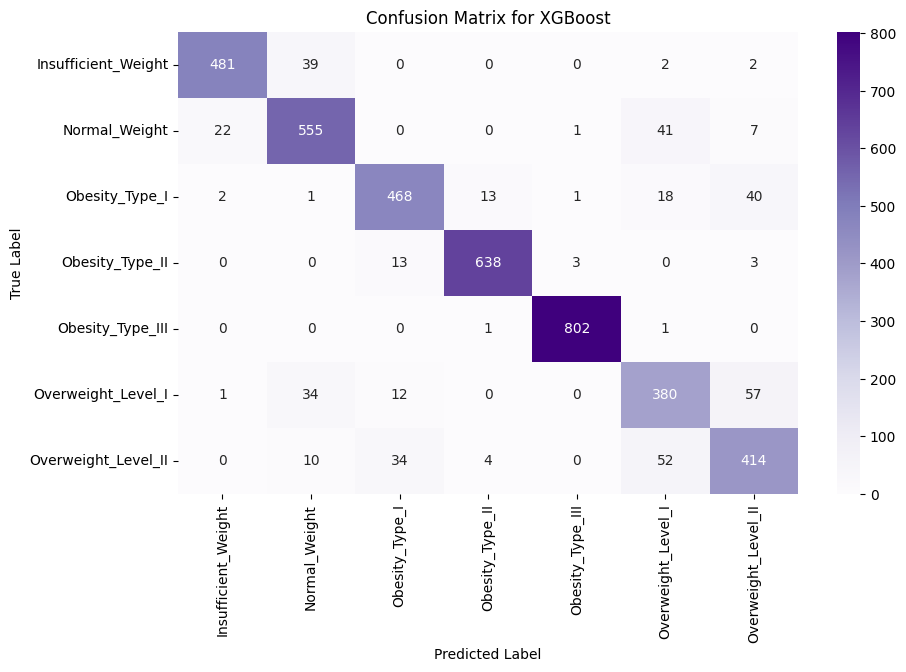

In [ ]:
# Define and train the XGBoost model
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# Evaluation metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy:  {acc_xgb:.4f}")
prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
print(f"Precision: {prec_xgb:.4f}")
rec_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
print(f"Recall:    {rec_xgb:.4f}")
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"F1 Score:  {f1_xgb:.4f}\n")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()


Below is the Grid Search for the best hyperparameters for XGBoosting for maximising the evaluation criterias.

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Accuracy Score: 0.9072023495604257

 Final Evaluation with Best XGBoost Model:
Accuracy:  0.9085
Precision: 0.9090
Recall:    0.9085
F1 Score:  0.9087


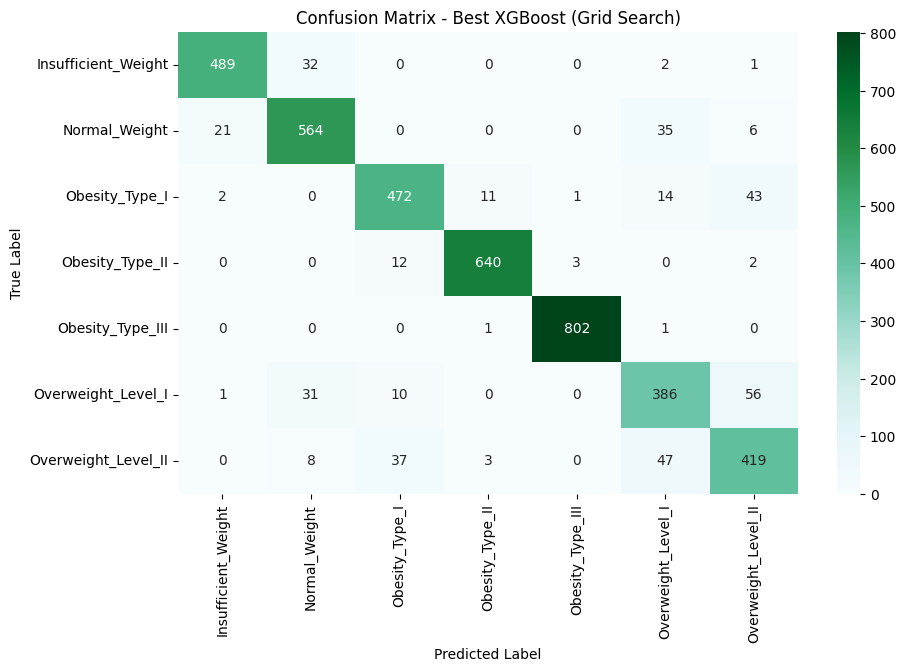

In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Set up the base model
xgb_base = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Can change this to 'f1_weighted' if needed
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

# Train final model with best parameters
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

# Final evaluation
acc_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
prec_best_xgb = precision_score(y_test, y_pred_best_xgb, average='weighted')
rec_best_xgb = recall_score(y_test, y_pred_best_xgb, average='weighted')
f1_best_xgb = f1_score(y_test, y_pred_best_xgb, average='weighted')

print("\n Final Evaluation with Best XGBoost Model:")
print(f"Accuracy:  {acc_best_xgb:.4f}")
print(f"Precision: {prec_best_xgb:.4f}")
print(f"Recall:    {rec_best_xgb:.4f}")
print(f"F1 Score:  {f1_best_xgb:.4f}")

# Confusion Matrix
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_best_xgb, annot=True, fmt='d', cmap='BuGn',
            xticklabels=label_encoder['NObeyesdad'].classes_,
            yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Best XGBoost (Grid Search)')
plt.show()


#### Gradient Boosting Classifier (max_depth = 4)

In this section, we train a Gradient Boosting Classifier using decision trees with a maximum depth of 4 as the base learners. Gradient Boosting is a powerful ensemble method that builds models sequentially, where each new model attempts to correct the errors made by the previous ones by minimizing the loss function's gradient.

####  Parameters:
- `n_estimators = 100`
- `max_depth = 4`
- `learning_rate = 0.1`
- `random_state = 42`


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       524
           1       0.88      0.89      0.88       626
           2       0.89      0.87      0.88       543
           3       0.97      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.78      0.79      0.78       484
           6       0.79      0.80      0.79       514

    accuracy                           0.90      4152
   macro avg       0.89      0.89      0.89      4152
weighted avg       0.90      0.90      0.90      4152

Accuracy:  0.9041
Precision: 0.9046
Recall:    0.9041
F1 Score:  0.9043



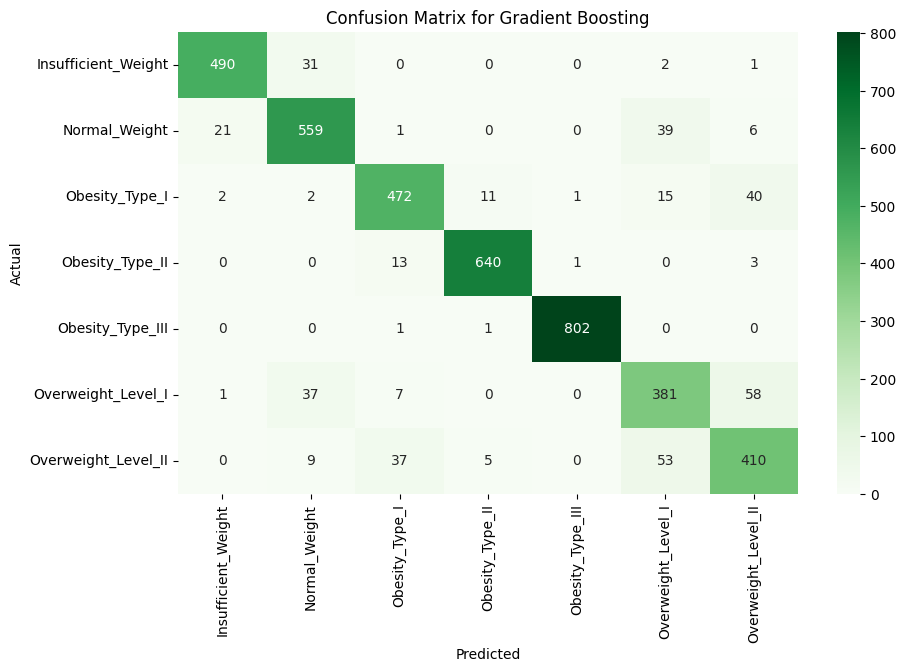

In [ ]:
# Train the Gradient Boosting model with max depth taken as 4
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_gb))

# Evaluating metrics for the same
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy:  {acc_gb:.4f}")
prec_gb = precision_score(y_test, y_pred_gb, average='weighted')
print(f"Precision: {prec_gb:.4f}")
rec_gb = recall_score(y_test, y_pred_gb, average='weighted')
print(f"Recall:    {rec_gb:.4f}")
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')
print(f"F1 Score:  {f1_gb:.4f}\n")

# Confusion Matrix for the same
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(10,6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()


Now we do the hyperparameter tuning for Gradient boosting. The code for this is given below.

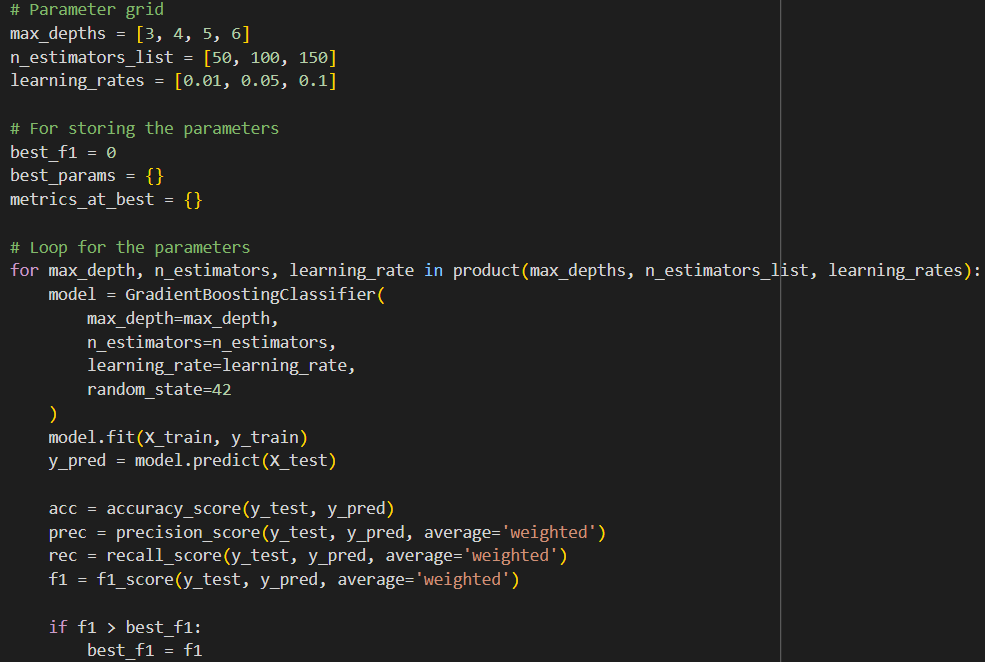

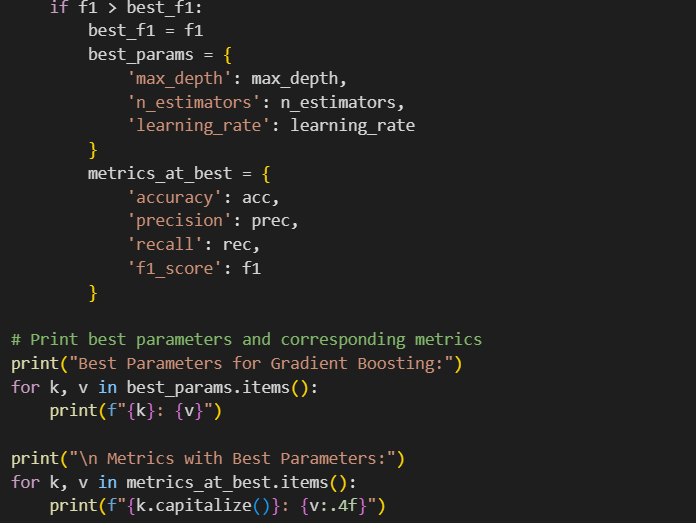

The above code takes approximately 20 minutes to run which is why I excluded it from this notebook. The results for the code above gives the following results.

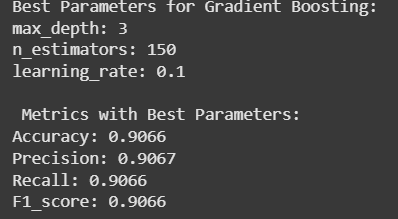

So the default gradient boosting model gives slightly better evaluation metrics than default XGBoost model but the XGBoost (tuned) gives better metrics than the tune Gradient Boost model.

## ->Stacking Classifier

Stacking is an ensemble learning technique that combines multiple classification models (called base learners) and trains a meta-model (usually a simple one like Logistic Regression which will also be the case here) to make the final prediction.

1. Multiple base models (e.g., Decision Tree, KNN, SVM) are trained on the dataset.
2. Their predictions are used as input features for a meta-classifier.
3. The meta-classifier learns to combine the base models' outputs to improve overall prediction accuracy.


Classification Report for Stacking Classifier:

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       524
           1       0.85      0.84      0.84       626
           2       0.86      0.85      0.86       543
           3       0.98      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.74      0.78      0.76       484
           6       0.77      0.77      0.77       514

    accuracy                           0.89      4152
   macro avg       0.87      0.87      0.87      4152
weighted avg       0.89      0.89      0.89      4152

Accuracy:  0.8856
Precision: 0.8865
Recall:    0.8856
F1 Score:  0.8860


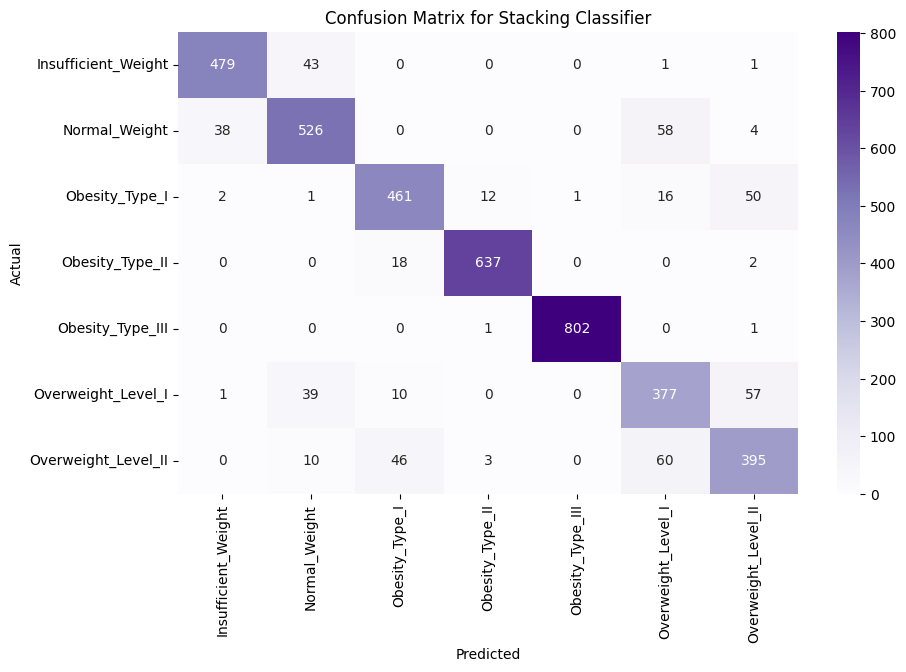

In [ ]:
# Defining the base learners that are going to be used in stacking (decision tree, KNN and Support vector Classifier).
# SVC is used just for having 3 base models for the stacking classification only in this model
base_learners = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
]

# Defining meta learner for the final step
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# Defining stacking classifier
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True,
    cv=5,
    n_jobs=-1,
)

# Training the stacking model
stack_model.fit(X_train, y_train)

# Predict on test set
y_pred_stack = stack_model.predict(X_test)

# Classificatinon report for the same
print("Classification Report for Stacking Classifier:\n")
print(classification_report(y_test, y_pred_stack))

# Individual metric scores for the same
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f"Accuracy:  {acc_stack:.4f}")
prec_stack = precision_score(y_test, y_pred_stack, average='weighted')
print(f"Precision: {prec_stack:.4f}")
rec_stack = recall_score(y_test, y_pred_stack, average='weighted')
print(f"Recall:    {rec_stack:.4f}")
f1_stack = f1_score(y_test, y_pred_stack, average='weighted')
print(f"F1 Score:  {f1_stack:.4f}")

# Confusion Matrix for stacking model
cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(10,6))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Stacking Classifier')
plt.show()

## ->Blending

Blending is a simplified form of stacking that combines the predictions of multiple base models using a meta-model. Unlike stacking, which uses cross-validation to generate out-of-fold predictions, blending relies on a hold-out validation set to train the meta-learner.

The training dataset is split into two parts:
   - **Base Training Set**: Used to train the base learners.
   - **Validation Set**: Used to get predictions from base learners, which serve as inputs for the meta-learner.

Each base model is trained on the base training set.

Predictions from the base models on the validation set are stacked together as new features.

A meta-learner is trained on these features and the actual validation labels.


Classification Report for Blending Ensemble:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       524
           1       0.82      0.83      0.82       626
           2       0.89      0.84      0.86       543
           3       0.97      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.72      0.76      0.74       484
           6       0.77      0.77      0.77       514

    accuracy                           0.88      4152
   macro avg       0.87      0.87      0.87      4152
weighted avg       0.88      0.88      0.88      4152

Accuracy:  0.8810
Precision: 0.8824
Recall:    0.8810
F1 Score:  0.8815


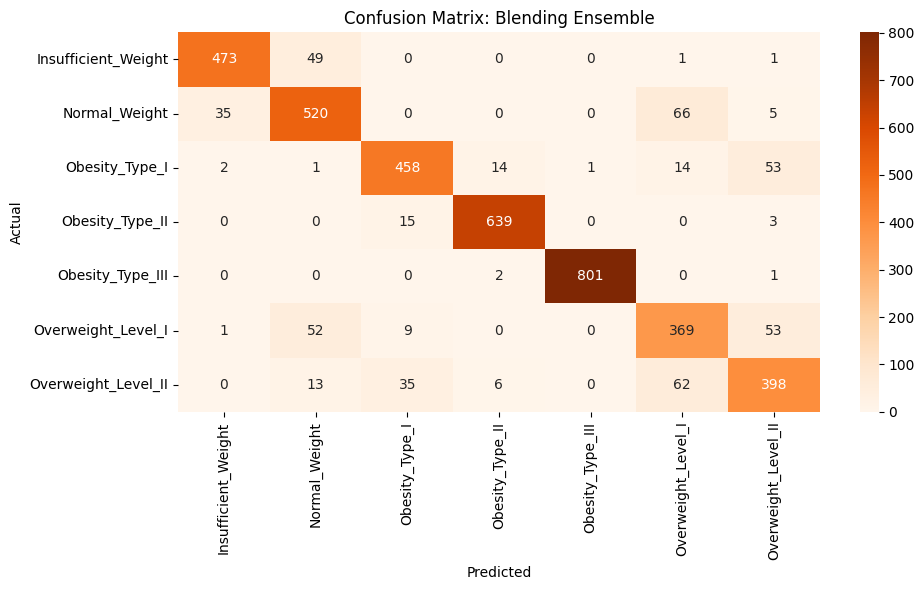

In [ ]:
# Split training set into base_train and val set for blending
X_base, X_val, y_base, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Defining the base models
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
]

# Training the base models on base set and geting the predictions on val set
val_preds = []

for name, model in base_models:
    model.fit(X_base, y_base)
    preds = model.predict_proba(X_val)
    val_preds.append(preds)

# Arrnaging the base model predictions horizontally as features for meta-learner
X_meta_train = np.hstack(val_preds)

# Training the meta-learner on this new feature set
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(X_meta_train, y_val)

# Predict test set using base model outputs
test_preds = []

for name, model in base_models:
    preds_test = model.predict_proba(X_test)
    test_preds.append(preds_test)

X_meta_test = np.hstack(test_preds)
y_pred_blend = meta_model.predict(X_meta_test)

# Classification report
print("Classification Report for Blending Ensemble:\n")
print(classification_report(y_test, y_pred_blend))

# Evaluating of metrics
acc_blend = accuracy_score(y_test, y_pred_blend)
print(f"Accuracy:  {acc_blend:.4f}")
prec_blend = precision_score(y_test, y_pred_blend, average='weighted')
print(f"Precision: {prec_blend:.4f}")
rec_blend = recall_score(y_test, y_pred_blend, average='weighted')
print(f"Recall:    {rec_blend:.4f}")
f1_blend = f1_score(y_test, y_pred_blend, average='weighted')
print(f"F1 Score:  {f1_blend:.4f}")

# Confusion matrix
cm_blend = confusion_matrix(y_test, y_pred_blend)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_blend, annot=True, fmt='d', cmap='Oranges', xticklabels=label_encoder['NObeyesdad'].classes_, yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Blending Ensemble')
plt.tight_layout()
plt.show()


## ->Voting & Weighted Voting

Voting is a straightforward ensemble learning technique where multiple models (called base learners) cast a "vote" for the final prediction. There are two types:

### Hard Voting:
- Each base model votes for a class label.
- The final prediction is the majority class.
- Best when all base models perform similarly.

### Soft Voting:
- Base models output predicted probabilities.
- The final prediction is based on the average probability (can also be weighted).
- More flexible and usually more accurate than hard voting.

### Weighted Voting (Soft Voting with Weights):
- Similar to soft voting, but gives higher influence to stronger models.
- Each model's predicted probability is multiplied by a weight.
- Improves performance when some base models are clearly better than others.



 Classification Report: Weighted Soft Voting
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       524
           1       0.84      0.82      0.83       626
           2       0.86      0.85      0.86       543
           3       0.96      0.98      0.97       657
           4       1.00      1.00      1.00       804
           5       0.73      0.75      0.74       484
           6       0.76      0.75      0.76       514

    accuracy                           0.88      4152
   macro avg       0.87      0.87      0.87      4152
weighted avg       0.88      0.88      0.88      4152

Accuracy:  0.8796
Precision: 0.8797
Recall:    0.8796
F1 Score:  0.8796

 Classification Report: Hard Voting
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       524
           1       0.85      0.81      0.83       626
           2       0.84      0.86      0.85       543
           3       0.97      0.

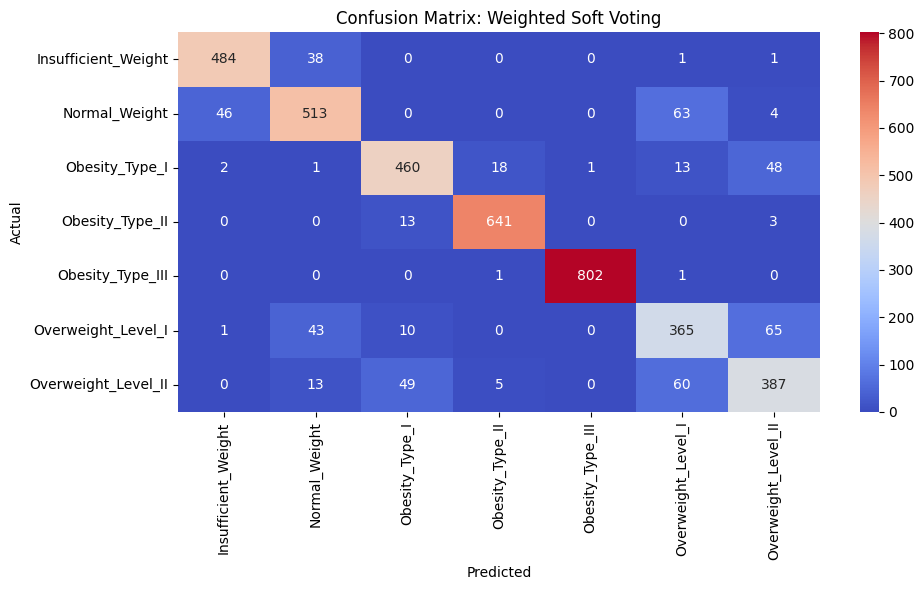

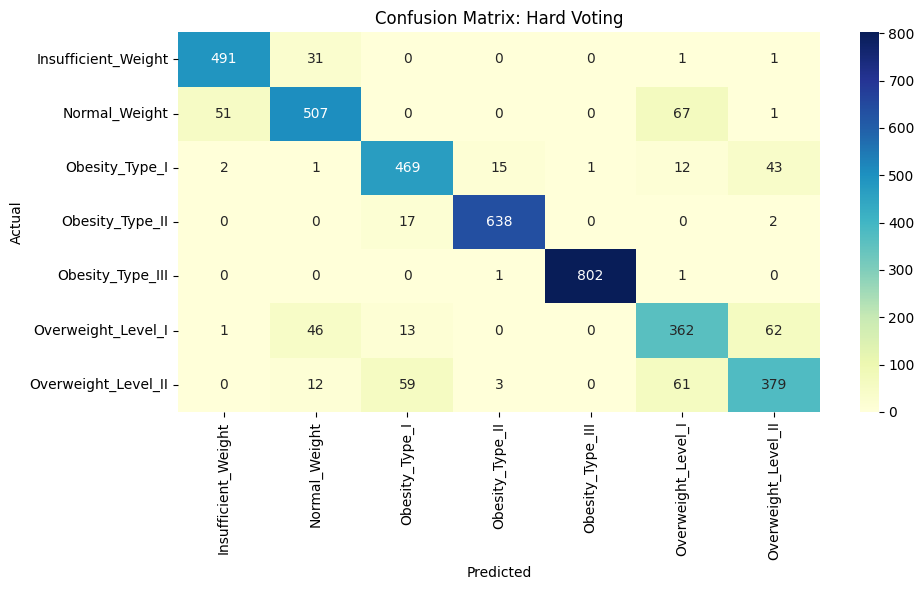

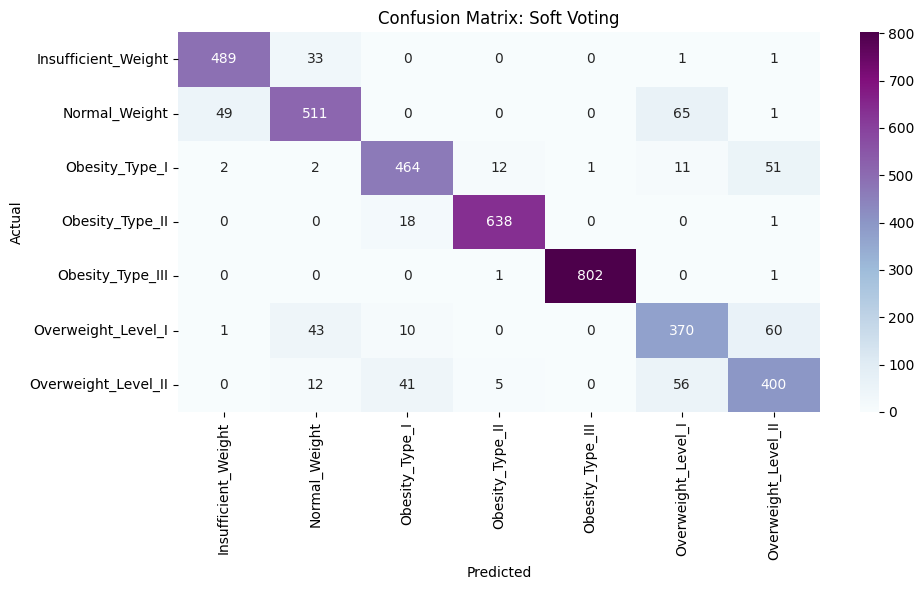

In [ ]:
# Base models (logistic regression, decision tree and SVC)
log_clf = LogisticRegression(max_iter=1000, random_state=42)
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
svc_clf = SVC(kernel='rbf', probability=True, random_state=42)

# 1. Hard Voting Classifier
voting_hard = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('svc', svc_clf)],
    voting='hard'
)
voting_hard.fit(X_train, y_train)
y_pred_hard = voting_hard.predict(X_test)

# 2. Weighted Soft Voting Classifier
voting_soft_weighted = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('svc', svc_clf)],
    voting='soft',
    weights=[2, 1, 3]  # More weight to SVC
)
voting_soft_weighted.fit(X_train, y_train)
y_pred_wsoft = voting_soft_weighted.predict(X_test)

# 3. Soft Voting (unweighted)
voting_soft = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('svc', svc_clf)],
    voting='soft'
)
voting_soft.fit(X_train, y_train)
y_pred_soft = voting_soft.predict(X_test)

# Evaluation Function for the metrics of each voting type
def evaluate_model(name, y_pred):
    print(f"\n Classification Report: {name}")
    print(classification_report(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    return acc, prec, rec, f1

# Evaluate all three
evaluate_model("Weighted Soft Voting", y_pred_wsoft)
evaluate_model("Hard Voting", y_pred_hard)
evaluate_model("Soft Voting", y_pred_soft)


# Confusion Matrix for weighted soft voting
cm_vote = confusion_matrix(y_test, y_pred_wsoft)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=label_encoder['NObeyesdad'].classes_,
            yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Weighted Soft Voting')
plt.tight_layout()
plt.show()

# Confusion Matrix for Hard Voting
cm_hard = confusion_matrix(y_test, y_pred_hard)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder['NObeyesdad'].classes_,
            yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Hard Voting')
plt.tight_layout()
plt.show()

# Confusion Matrix: Soft Voting
cm_soft = confusion_matrix(y_test, y_pred_soft)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='BuPu',
            xticklabels=label_encoder['NObeyesdad'].classes_,
            yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Soft Voting')
plt.tight_layout()
plt.show()

#### Model Diversity in Ensemble Learning

To improve the performance and generalization of our ensemble model, we apply model diversity, which ensures the base models vary in the following ways:

- **Different algorithms**: Using Logistic Regression, Decision Trees, etc
- **Different hyperparameters**: Changing settings like `max_depth`, `C`, and `kernel` across models.
- **Different subsets of features**: Training each model on a different part of the dataset.



Below is the grid search for all three traditional ML models to find the best hyperparameters for each.


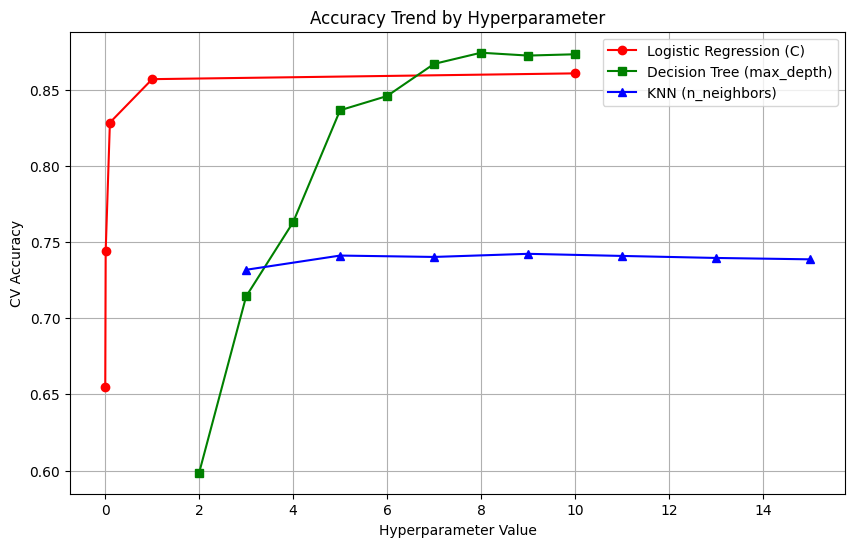

Best Parameters & Accuracy
Logistic Regression → C = 10 | Accuracy = 0.8606
Decision Tree       → max_depth = 8 | Accuracy = 0.8741
KNN                 → n_neighbors = 9 | Accuracy = 0.7422


In [ ]:
# Define parameter grids
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10]}
param_grid_dt = {'max_depth': list(range(2, 11))}
param_grid_knn = {'n_neighbors': list(range(3, 16, 2))}

# Grid search for Logistic Regression
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy'
)
grid_lr.fit(X_train, y_train)

# Grid search for Decision Tree
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy'
)
grid_dt.fit(X_train, y_train)

# Grid search for KNN
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy'
)
grid_knn.fit(X_train, y_train)

# Extract data for plotting
lr_x = grid_lr.cv_results_['param_C'].data
lr_y = grid_lr.cv_results_['mean_test_score']

dt_x = grid_dt.cv_results_['param_max_depth'].data
dt_y = grid_dt.cv_results_['mean_test_score']

knn_x = grid_knn.cv_results_['param_n_neighbors'].data
knn_y = grid_knn.cv_results_['mean_test_score']

# Plot all three on same graph
plt.figure(figsize=(10, 6))
plt.plot(lr_x, lr_y, marker='o', label='Logistic Regression (C)', color='red')
plt.plot(dt_x, dt_y, marker='s', label='Decision Tree (max_depth)', color='green')
plt.plot(knn_x, knn_y, marker='^', label='KNN (n_neighbors)', color='blue')
plt.title('Accuracy Trend by Hyperparameter')
plt.xlabel('Hyperparameter Value')
plt.ylabel('CV Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Print Best Parameters
print("Best Parameters & Accuracy")
print(f"Logistic Regression → C = {grid_lr.best_params_['C']} | Accuracy = {grid_lr.best_score_:.4f}")
print(f"Decision Tree       → max_depth = {grid_dt.best_params_['max_depth']} | Accuracy = {grid_dt.best_score_:.4f}")
print(f"KNN                 → n_neighbors = {grid_knn.best_params_['n_neighbors']} | Accuracy = {grid_knn.best_score_:.4f}")


Below is the stacking model with model diversity

Classification Report for Stacking with Model Diversity:

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       524
           1       0.84      0.85      0.84       626
           2       0.81      0.83      0.82       543
           3       0.96      0.95      0.96       657
           4       1.00      1.00      1.00       804
           5       0.72      0.68      0.70       484
           6       0.70      0.72      0.71       514

    accuracy                           0.86      4152
   macro avg       0.85      0.85      0.85      4152
weighted avg       0.86      0.86      0.86      4152

Accuracy:  0.8649
Precision: 0.8644
Recall:    0.8649
F1 Score:  0.8645


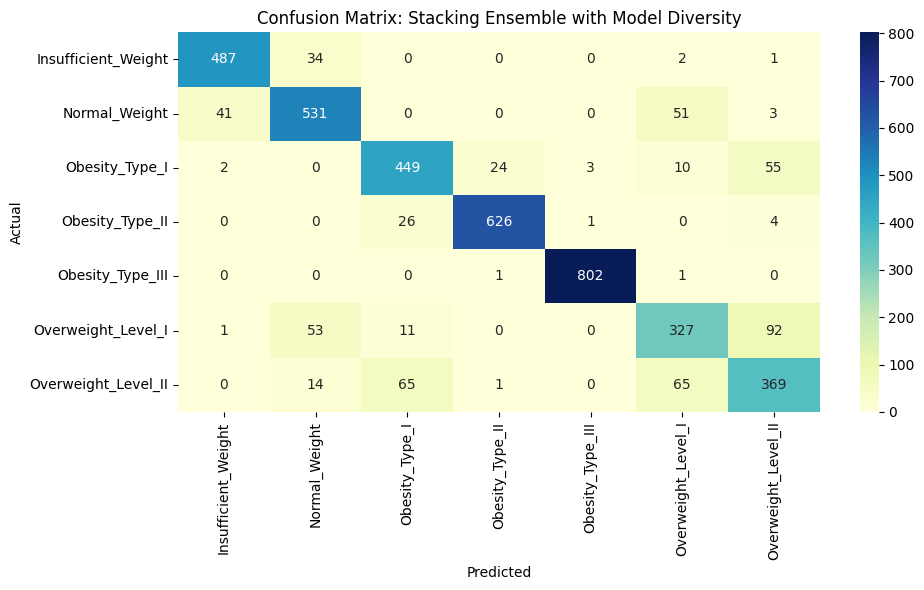

In [ ]:
# Save original feature names before scaling
feature_names = X.columns

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Converting back to DataFrames
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)


# Selecting feature subsets for each model
features_logreg = X.columns[:8]     # First 8 features
features_knn = X.columns[8:16]      # Next 8 features
features_dt = X.columns[4:]         # From 5th feature onwards

# Helper to select columns
def column_selector(cols):
    return FunctionTransformer(lambda X: X[cols], validate=False)

# Pipelines for each base model with selected features
logreg_pipe = Pipeline([
    ('select', column_selector(features_logreg)),
    ('model', LogisticRegression(C=0.5, max_iter=1000, random_state=42))
])

knn_pipe = Pipeline([
    ('select', column_selector(features_knn)),
    ('model', KNeighborsClassifier(n_neighbors=15))
])

dt_pipe = Pipeline([
    ('select', column_selector(features_dt)),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=42))
])

# Defining the stacking model
stacking_modeldiv = StackingClassifier(
    estimators=[
        ('logreg', logreg_pipe),
        ('knn', knn_pipe),
        ('dt', dt_pipe)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

# Fitting the stacking model
stacking_modeldiv.fit(X_train, y_train)

# Predictions
y_pred_stackdiv = stacking_modeldiv.predict(X_test)

# Classification Report
print("Classification Report for Stacking with Model Diversity:\n")
print(classification_report(y_test, y_pred_stackdiv))

# Evaluation Metrics
acc_stackdiv = accuracy_score(y_test, y_pred_stackdiv)
print(f"Accuracy:  {acc_stackdiv:.4f}")
prec_stackdiv = precision_score(y_test, y_pred_stackdiv, average='weighted')
print(f"Precision: {prec_stackdiv:.4f}")
rec_stackdiv = recall_score(y_test, y_pred_stackdiv, average='weighted')
print(f"Recall:    {rec_stackdiv:.4f}")
f1_stackdiv = f1_score(y_test, y_pred_stackdiv, average='weighted')
print(f"F1 Score:  {f1_stackdiv:.4f}")

# Confusion Matrix
cm_stackdiv = confusion_matrix(y_test, y_pred_stackdiv)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_stackdiv, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder['NObeyesdad'].classes_,
            yticklabels=label_encoder['NObeyesdad'].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Stacking Ensemble with Model Diversity')
plt.tight_layout()
plt.show()


Now lets compare every single method used which includes the traditional ML models as well as the ensemble models.

In [ ]:
# Combine all ensemble models
all_models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "KNN": knn_model,
    "Bagging (Random Forest)": rf_model,
    "Adaboost": ada_model,
    "XGboosting": best_xgb,
    "Gradient Boosting": gb_model,
    "Blending": meta_model,
    "Hard Voting": voting_hard,
    "Soft Voting": voting_soft,
    "Weighted Soft Voting": voting_soft_weighted,
    "Stacking (Basic)": stack_model,
    "Stacking (Diverse)": stacking_modeldiv
}

# Initialising an empty list to store results
results = []

# Appending the results
for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, acc, prec, rec, f1])

#  Create and show table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Final Model Comparison Table")
display(results_df)

Final Model Comparison Table


,Model,Accuracy,Precision,Recall,F1 Score
0,XGboosting,0.908478,0.908957,0.908478,0.908667
1,Gradient Boosting,0.904143,0.904589,0.904143,0.904324
2,Bagging (Random Forest),0.895954,0.896167,0.895954,0.895908
3,Adaboost,0.893545,0.893585,0.893545,0.893546
4,Stacking (Basic),0.885356,0.886316,0.885356,0.885746
5,Soft Voting,0.884634,0.885012,0.884634,0.884720
6,Weighted Soft Voting,0.879576,0.879720,0.879576,0.879560
7,Hard Voting,0.878854,0.878875,0.878854,0.878622
8,Stacking (Diverse),0.864884,0.864371,0.864884,0.864531
9,Logistic Regression,0.862717,0.861181,0.862717,0.861584


The model with that gives the best results is the XGBoost model.

Ended:::